# Python, Pandas & Seaborn for Banking Analytics

A hands-on workshop for exploring banking data using Python's most powerful data manipulation and visualization libraries.

## Prerequisites
- Run `banking_data_creation.ipynb` first to create the SQLite database

## Workshop Agenda
1. **Setup & Data Loading** - Connect to SQLite and load banking data
2. **Pandas Fundamentals** - DataFrames, Series, and basic operations
3. **Data Cleaning & Preparation** - Handling data types and transformations
4. **Exploratory Data Analysis** - Summarizing and understanding banking metrics
5. **Banking Analytics** - Customer segmentation, transaction analysis, risk metrics
6. **Data Visualization** - Creating informative charts with Seaborn

---
*Let's get started!*

In [47]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")

Pandas: 2.3.0
NumPy: 2.3.0
Seaborn: 0.13.2


## 1. Load Data from SQLite Database

In [48]:
db_path = 'data/banking_data.db'
conn = sqlite3.connect(db_path)

customers = pd.read_sql('SELECT * FROM customers', conn)
transactions = pd.read_sql('SELECT * FROM transactions', conn)
loans = pd.read_sql('SELECT * FROM loans', conn)

conn.close()

print(f"Loaded data:")
print(f"  - Customers: {len(customers)} rows")
print(f"  - Transactions: {len(transactions)} rows")
print(f"  - Loans: {len(loans)} rows")

Loaded data:
  - Customers: 500 rows
  - Transactions: 2000 rows
  - Loans: 150 rows


In [49]:
customers.head()

,customer_id,first_name,last_name,age,city,account_type,segment,credit_score,annual_income,years_as_customer,credit_limit
0,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692
1,CUST000002,Patricia,Gonzalez,30,Phoenix,Checking,Retail,708,196277,4,14940
2,CUST000003,Richard,Jones,54,San Diego,Checking,Private,642,110811,28,8924
3,CUST000004,Joseph,Thomas,74,San Jose,Business,Premium,688,85103,12,33054
4,CUST000005,David,Miller,41,New York,Premium Checking,Corporate,600,231884,6,14783


In [50]:
transactions.head()

,transaction_id,customer_id,transaction_date,transaction_type,category,amount
0,TXN00000001,CUST000377,2025-11-14,Payment,Travel,354.28
1,TXN00000002,CUST000152,2025-12-24,Deposit,Travel,2048.31
2,TXN00000003,CUST000198,2025-06-04,Refund,Utilities,66.12
3,TXN00000004,CUST000273,2026-02-16,Deposit,Travel,931.94
4,TXN00000005,CUST000156,2025-08-13,Withdrawal,Online Transfer,232.80


In [51]:
loans.head()

,loan_id,customer_id,loan_type,loan_amount,interest_rate,loan_term_months,monthly_payment,outstanding_balance,status,start_date
0,LOAN000001,CUST000296,Home Mortgage,206275,15.65,24,10065.40,0.00,Paid Off,2026-02-11
1,LOAN000002,CUST000286,Auto,187178,11.39,180,2173.52,107908.41,Default,2026-11-11
2,LOAN000003,CUST000281,Business,229497,14.20,360,2755.62,232046.97,Active,2026-08-05
3,LOAN000004,CUST000007,Home Mortgage,96676,14.96,180,1350.42,76388.16,Default,2025-05-02
4,LOAN000005,CUST000092,Business,87506,10.94,36,2862.35,0.00,Paid Off,2025-10-26


## 2. Pandas Fundamentals

### Understanding DataFrames and Series

In [52]:
print("=== CUSTOMERS DATAFRAME ===")
print(f"Shape: {customers.shape}")
print(f"\nColumn names:\n{customers.columns.tolist()}")
print(f"\nData types:\n{customers.dtypes}")

=== CUSTOMERS DATAFRAME ===
Shape: (500, 11)

Column names:
['customer_id', 'first_name', 'last_name', 'age', 'city', 'account_type', 'segment', 'credit_score', 'annual_income', 'years_as_customer', 'credit_limit']

Data types:
customer_id          object
first_name           object
last_name            object
age                   int64
city                 object
account_type         object
segment              object
credit_score          int64
annual_income         int64
years_as_customer     int64
credit_limit          int64
dtype: object


In [53]:
print("Statistical summary:")
customers.describe()

Statistical summary:


,age,credit_score,annual_income,years_as_customer,credit_limit
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.510000,714.854000,141613.000000,15.226000,18771.592000
std,15.573406,76.642134,63982.781253,8.562099,16671.757208
min,22.000000,580.000000,32204.000000,1.000000,0.000000
25%,34.000000,646.000000,84284.750000,7.000000,0.000000
50%,47.000000,716.500000,141400.500000,16.000000,17072.000000
75%,61.000000,780.000000,196481.000000,23.000000,33898.500000
max,74.000000,849.000000,249968.000000,29.000000,49757.000000


### Selecting Data

In [54]:
ages = customers['age']
print(f"Type: {type(ages)}")
print(f"\nFirst 5 ages:\n{ages.head()}")

Type: <class 'pandas.core.series.Series'>

First 5 ages:
0    38
1    30
2    54
3    74
4    41
Name: age, dtype: int64


In [55]:
customer_subset = customers[['customer_id', 'first_name', 'last_name', 'city', 'segment']]
print("Customer subset:")
customer_subset.head()

Customer subset:


,customer_id,first_name,last_name,city,segment
0,CUST000001,Michael,Anderson,San Diego,Premium
1,CUST000002,Patricia,Gonzalez,Phoenix,Retail
2,CUST000003,Richard,Jones,San Diego,Private
3,CUST000004,Joseph,Thomas,San Jose,Premium
4,CUST000005,David,Miller,New York,Corporate


In [56]:
print("Rows 10-15:")
customers.iloc[10:16]

Rows 10-15:


,customer_id,first_name,last_name,age,city,account_type,segment,credit_score,annual_income,years_as_customer,credit_limit
10,CUST000011,John,Rodriguez,67,San Diego,Savings,Retail,802,214456,13,30074
11,CUST000012,Michael,Martinez,56,Dallas,Business,Private,638,166865,23,9917
12,CUST000013,David,Anderson,27,Philadelphia,Checking,Premium,826,166643,26,43599
13,CUST000014,David,Garcia,39,Austin,Business,Retail,707,177281,18,30832
14,CUST000015,Linda,Martinez,72,San Antonio,Business,Retail,604,143550,5,0
15,CUST000016,Robert,Williams,26,New York,Checking,Private,710,204220,25,25706


In [57]:
print("Customer CUST000001:")
customers.loc[customers['customer_id'] == 'CUST000001']

Customer CUST000001:


,customer_id,first_name,last_name,age,city,account_type,segment,credit_score,annual_income,years_as_customer,credit_limit
0,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692


## 3. Filtering and Conditionals

In [58]:
premium_customers = customers[customers['segment'] == 'Premium']
print(f"Premium customers: {len(premium_customers)}")
premium_customers.head()

Premium customers: 123


,customer_id,first_name,last_name,age,city,account_type,segment,credit_score,annual_income,years_as_customer,credit_limit
0,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692
3,CUST000004,Joseph,Thomas,74,San Jose,Business,Premium,688,85103,12,33054
12,CUST000013,David,Anderson,27,Philadelphia,Checking,Premium,826,166643,26,43599
20,CUST000021,Jennifer,Thomas,51,Philadelphia,Premium Checking,Premium,768,159714,25,28666
25,CUST000026,Susan,Anderson,22,San Antonio,Business,Premium,792,74760,4,15234


In [59]:
high_value = customers[(customers['annual_income'] > 100000) & 
                       (customers['credit_score'] > 700) &
                       (customers['segment'].isin(['Premium', 'Private']))]
print(f"High-value customers: {len(high_value)}")
high_value.head()

High-value customers: 66


,customer_id,first_name,last_name,age,city,account_type,segment,credit_score,annual_income,years_as_customer,credit_limit
12,CUST000013,David,Anderson,27,Philadelphia,Checking,Premium,826,166643,26,43599
15,CUST000016,Robert,Williams,26,New York,Checking,Private,710,204220,25,25706
20,CUST000021,Jennifer,Thomas,51,Philadelphia,Premium Checking,Premium,768,159714,25,28666
35,CUST000036,Richard,Garcia,48,Phoenix,Business,Premium,759,219344,16,49757
42,CUST000043,Elizabeth,Williams,22,Austin,Business,Premium,718,232440,9,0


In [60]:
target_cities = ['New York', 'Los Angeles', 'Chicago']
metro_customers = customers[customers['city'].isin(target_cities)]
print(f"Customers in NYC/LA/Chicago: {len(metro_customers)}")

Customers in NYC/LA/Chicago: 137


In [61]:
j_customers = customers[customers['first_name'].str.startswith('J')]
print(f"Customers with first name starting with 'J': {len(j_customers)}")

Customers with first name starting with 'J': 166


## 4. Sorting and Ranking

In [62]:
sorted_by_income = customers.sort_values('annual_income', ascending=False)
print("Top 10 highest income customers:")
sorted_by_income[['customer_id', 'first_name', 'last_name', 'annual_income', 'segment']].head(10)

Top 10 highest income customers:


,customer_id,first_name,last_name,annual_income,segment
325,CUST000326,Jennifer,Brown,249968,Retail
179,CUST000180,John,Martinez,249911,Premium
478,CUST000479,James,Davis,249763,Retail
259,CUST000260,David,Miller,249581,Retail
491,CUST000492,Richard,Lopez,249526,Retail
220,CUST000221,David,Johnson,249402,Premium
57,CUST000058,William,Wilson,248664,Retail
409,CUST000410,Susan,Wilson,248512,Retail
406,CUST000407,Jennifer,Martinez,247192,Private
67,CUST000068,William,Thomas,247064,Corporate


In [63]:
sorted_multi = customers.sort_values(['segment', 'annual_income'], ascending=[True, False])
print("Customers sorted by segment (asc), then income (desc):")
sorted_multi[['customer_id', 'segment', 'annual_income']].head(10)

Customers sorted by segment (asc), then income (desc):


,customer_id,segment,annual_income
67,CUST000068,Corporate,247064
448,CUST000449,Corporate,243606
342,CUST000343,Corporate,242123
54,CUST000055,Corporate,241814
429,CUST000430,Corporate,241142
68,CUST000069,Corporate,239932
205,CUST000206,Corporate,239329
425,CUST000426,Corporate,237129
8,CUST000009,Corporate,232346
4,CUST000005,Corporate,231884


## 5. Adding and Transforming Columns

In [64]:
customers['full_name'] = customers['first_name'] + ' ' + customers['last_name']

def categorize_income(income):
    if income < 50000:
        return 'Low'
    elif income < 100000:
        return 'Middle'
    elif income < 200000:
        return 'Upper-Middle'
    else:
        return 'High'

customers['income_tier'] = customers['annual_income'].apply(categorize_income)

customers['customer_value'] = (customers['annual_income'] * 0.4 + 
                              customers['credit_score'] * 100 +
                              customers['years_as_customer'] * 500)

print("Customers with new calculated columns:")
customers[['customer_id', 'full_name', 'annual_income', 'income_tier', 'customer_value']].head()

Customers with new calculated columns:


,customer_id,full_name,annual_income,income_tier,customer_value
0,CUST000001,Michael Anderson,183512,Upper-Middle,140404.8
1,CUST000002,Patricia Gonzalez,196277,Upper-Middle,151310.8
2,CUST000003,Richard Jones,110811,Upper-Middle,122524.4
3,CUST000004,Joseph Thomas,85103,Middle,108841.2
4,CUST000005,David Miller,231884,High,155753.6


In [65]:
customers['age_group'] = customers['age'].apply(lambda x: 
    'Young (22-35)' if x < 35 else 
    ('Middle (35-55)' if x < 55 else 'Senior (55+)'))

customers[['customer_id', 'age', 'age_group', 'segment']].head(10)

,customer_id,age,age_group,segment
0,CUST000001,38,Middle (35-55),Premium
1,CUST000002,30,Young (22-35),Retail
2,CUST000003,54,Middle (35-55),Private
3,CUST000004,74,Senior (55+),Premium
4,CUST000005,41,Middle (35-55),Corporate
5,CUST000006,34,Young (22-35),Retail
6,CUST000007,49,Middle (35-55),Retail
7,CUST000008,69,Senior (55+),Retail
8,CUST000009,50,Middle (35-55),Corporate
9,CUST000010,34,Young (22-35),Retail


## 6. Aggregation with groupby()

In [66]:
print("Average income by segment:")
customers.groupby('segment')['annual_income'].mean().round(2)

Average income by segment:


segment
Corporate    143387.87
Premium      137486.93
Private      145910.67
Retail       142256.27
Name: annual_income, dtype: float64

In [67]:
segment_stats = customers.groupby('segment').agg({
    'annual_income': ['mean', 'median', 'min', 'max', 'count'],
    'credit_score': ['mean', 'min', 'max'],
    'years_as_customer': 'mean'
}).round(2)

segment_stats

annual_income                                credit_score            \
                   mean    median    min     max count         mean  min  max   
segment                                                                         
Corporate     143387.87  142230.0  32204  247064   105       705.12  580  849   
Premium       137486.93  134601.0  33866  249911   123       722.76  581  846   
Private       145910.67  168046.0  41308  247192    40       720.02  584  847   
Retail        142256.27  144170.0  32257  249968   232       714.18  580  848   

          years_as_customer  
                       mean  
segment                      
Corporate             15.70  
Premium               14.72  
Private               15.15  
Retail                15.29

In [68]:
city_segment = customers.groupby(['city', 'segment']).agg({
    'annual_income': 'mean',
    'customer_id': 'count'
}).round(2)
city_segment.columns = ['avg_income', 'customer_count']
city_segment

avg_income  customer_count
city         segment                              
Austin       Corporate   122071.09              11
             Premium     138498.73              11
             Private     161161.67               3
             Retail      137491.44              16
Chicago      Corporate    93974.00               6
             Premium     133702.58              12
             Private     172420.33               3
             Retail      150002.46              24
Dallas       Corporate   156865.12               8
             Premium     119375.57               7
             Private     194428.00               3
             Retail      124171.54              28
Houston      Corporate   177122.12               8
             Premium     138761.38               8
             Private      61345.50               2
             Retail      150868.08              13
Jacksonville Corporate   123269.33               9
             Premium     107612.00               7
             Private      66587.50               2
             Retail      151157.38              13
Los Angeles  Corporate   129505.50               6
             Premium     111154.62              16
             Private      65932.50               4
             Retail      151115.56              18
New York     Corporate   141860.60              10
             Premium     184237.55              11
             Private     157624.50               2
             Retail      124754.64              25
Philadelphia Corporate   157884.36              11
             Premium     162658.09              11
             Private     138289.75               4
             Retail      149586.00              11
Phoenix      Corporate   169582.60              10
             Premium     134793.00              15
             Retail      132538.47              19
San Antonio  Corporate   112397.33               6
             Premium     138066.80              10
             Private     167814.78               9
             Retail      140235.30              23
San Diego    Corporate   153215.10              10
             Premium     115654.67               6
             Private     162259.33               3
             Retail      152238.67              24
San Jose     Corporate   153305.00              10
             Premium     154795.00               9
             Private     173456.40               5
             Retail      162146.39              18

In [69]:
city_segment_reset = city_segment.reset_index()
city_segment_reset.head(10)

,city,segment,avg_income,customer_count
0,Austin,Corporate,122071.09,11
1,Austin,Premium,138498.73,11
2,Austin,Private,161161.67,3
3,Austin,Retail,137491.44,16
4,Chicago,Corporate,93974.00,6
5,Chicago,Premium,133702.58,12
6,Chicago,Private,172420.33,3
7,Chicago,Retail,150002.46,24
8,Dallas,Corporate,156865.12,8
9,Dallas,Premium,119375.57,7


## 7. Merging DataFrames

In [70]:
customer_loans = customers.merge(loans, on='customer_id', how='left')
print(f"Merged dataset shape: {customer_loans.shape}")
print(f"Customers with loans: {customer_loans['loan_id'].notna().sum()}")
customer_loans[['customer_id', 'full_name', 'segment', 'loan_type', 'loan_amount', 'status']].head(10)

Merged dataset shape: (521, 24)
Customers with loans: 150


,customer_id,full_name,segment,loan_type,loan_amount,status
0,CUST000001,Michael Anderson,Premium,Auto,85729.0,Paid Off
1,CUST000001,Michael Anderson,Premium,Business,76520.0,Active
2,CUST000002,Patricia Gonzalez,Retail,NaN,NaN,NaN
3,CUST000003,Richard Jones,Private,NaN,NaN,NaN
4,CUST000004,Joseph Thomas,Premium,Student,110885.0,Active
5,CUST000005,David Miller,Corporate,NaN,NaN,NaN
6,CUST000006,Linda Smith,Retail,Home Mortgage,243221.0,Active
7,CUST000007,Richard Thomas,Retail,Home Mortgage,96676.0,Default
8,CUST000007,Richard Thomas,Retail,Student,48042.0,Pending
9,CUST000008,Robert Williams,Retail,NaN,NaN,NaN


In [71]:
customer_transactions = customers.merge(transactions, on='customer_id', how='inner')
print(f"Transactions with customer info: {customer_transactions.shape[0]} rows")
customer_transactions.head()

Transactions with customer info: 2000 rows


,customer_id,first_name,last_name,age,city,account_type,segment,credit_score,annual_income,years_as_customer,credit_limit,full_name,income_tier,customer_value,age_group,transaction_id,transaction_date,transaction_type,category,amount
0,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692,Michael Anderson,Upper-Middle,140404.8,Middle (35-55),TXN00000639,2025-08-01,Deposit,Dining,877.47
1,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692,Michael Anderson,Upper-Middle,140404.8,Middle (35-55),TXN00000717,2025-10-03,Withdrawal,Healthcare,244.08
2,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692,Michael Anderson,Upper-Middle,140404.8,Middle (35-55),TXN00001533,2025-10-21,Payment,Bill Payment,167.51
3,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692,Michael Anderson,Upper-Middle,140404.8,Middle (35-55),TXN00001536,2025-09-21,Refund,Healthcare,479.05
4,CUST000001,Michael,Anderson,38,San Diego,Business,Premium,595,183512,15,46692,Michael Anderson,Upper-Middle,140404.8,Middle (35-55),TXN00001815,2025-04-24,Transfer,Payroll,193.57


## 8. Banking Analytics Examples

In [72]:
customer_totals = transactions.groupby('customer_id').agg({
    'amount': ['sum', 'mean', 'count'],
    'transaction_date': 'max'
}).round(2)
customer_totals.columns = ['total_amount', 'avg_amount', 'transaction_count', 'last_transaction']
customer_totals = customer_totals.reset_index()

customers_with_activity = customers.merge(customer_totals, on='customer_id', how='left')
customers_with_activity['transaction_count'] = customers_with_activity['transaction_count'].fillna(0).astype(int)

print("Customer activity summary:")
customers_with_activity[['customer_id', 'full_name', 'segment', 'total_amount', 'transaction_count']].head(10)

Customer activity summary:


,customer_id,full_name,segment,total_amount,transaction_count
0,CUST000001,Michael Anderson,Premium,1961.68,5
1,CUST000002,Patricia Gonzalez,Retail,2876.08,5
2,CUST000003,Richard Jones,Private,2257.05,5
3,CUST000004,Joseph Thomas,Premium,5426.03,8
4,CUST000005,David Miller,Corporate,1680.42,3
5,CUST000006,Linda Smith,Retail,3527.99,4
6,CUST000007,Richard Thomas,Retail,371.79,3
7,CUST000008,Robert Williams,Retail,957.18,2
8,CUST000009,Michael Thomas,Corporate,383.42,4
9,CUST000010,Elizabeth Johnson,Retail,3265.61,5


In [73]:
print("=== LOAN PORTFOLIO SUMMARY ===\n")

print("Loans by status:")
loans.groupby('status').agg({
    'loan_amount': ['count', 'sum', 'mean'],
    'outstanding_balance': 'sum'
}).round(2)

=== LOAN PORTFOLIO SUMMARY ===

Loans by status:


loan_amount                      outstanding_balance
               count       sum       mean                 sum
status                                                       
Active            84  10660548  126911.29         10712292.81
Default           14   1585430  113245.00          1082465.31
Paid Off          38   4574297  120376.24                0.00
Pending           14   2045102  146078.71                0.00

In [74]:
total_loans = len(loans)
defaulted_loans = len(loans[loans['status'] == 'Default'])
delinquency_rate = (defaulted_loans / total_loans) * 100
print(f"Total loans: {total_loans}")
print(f"Defaulted loans: {defaulted_loans}")
print(f"Delinquency rate: {delinquency_rate:.2f}%")

Total loans: 150
Defaulted loans: 14
Delinquency rate: 9.33%


In [75]:
print("Average interest rate by loan type:")
loans.groupby('loan_type').agg({
    'interest_rate': 'mean',
    'loan_amount': 'mean',
    'monthly_payment': 'mean',
    'loan_id': 'count'
}).round(2).rename(columns={'loan_id': 'loan_count'})

Average interest rate by loan type:


,interest_rate,loan_amount,monthly_payment,loan_count
loan_type,,,,
Auto,10.05,123572.90,3650.66,31
Business,10.52,121246.76,3974.99,34
Home Mortgage,10.01,140058.31,5513.67,32
Personal,12.73,127947.81,3075.82,21
Student,11.40,116983.03,3336.82,32


## 9. Data Visualization with Seaborn

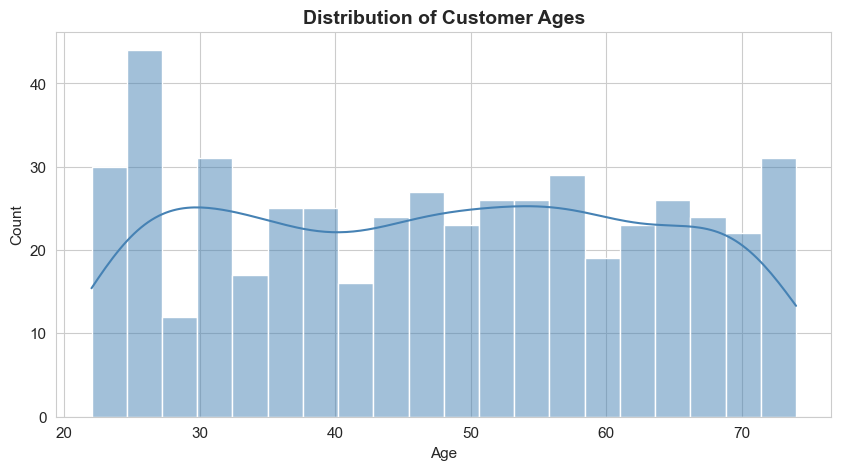

In [94]:
plt.figure(figsize=(10, 5))
sns.histplot(data=customers, x='age', bins=20, color='steelblue', kde=True)
plt.title('Distribution of Customer Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

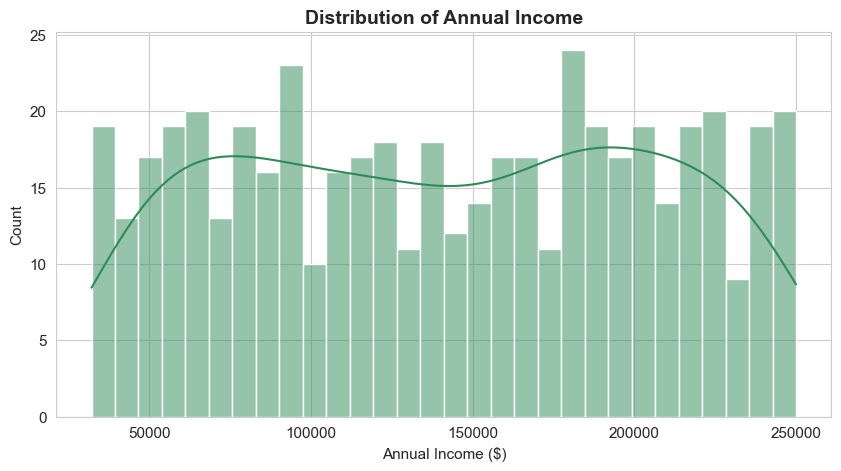

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(data=customers, x='annual_income', bins=30, color='seagreen', kde=True)
plt.title('Distribution of Annual Income', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income ($)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

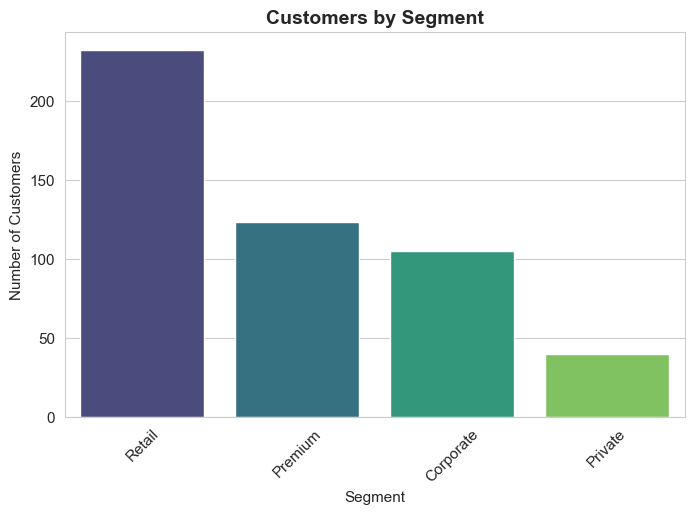

In [122]:
plt.figure(figsize=(8, 5))
segment_counts = customers['segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, palette='viridis')
plt.title('Customers by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

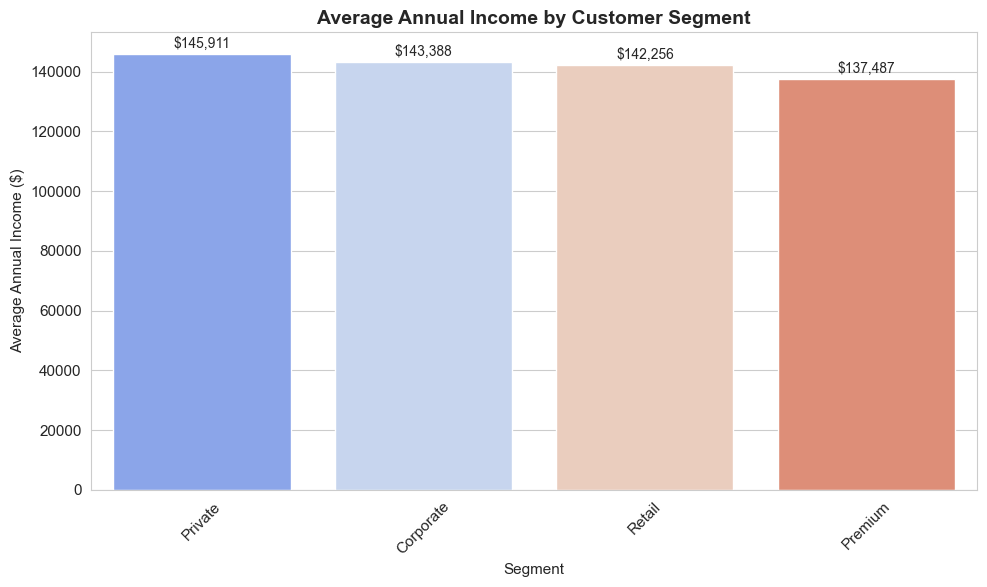

In [120]:
plt.figure(figsize=(10, 6))
segment_income = customers.groupby('segment')['annual_income'].mean().sort_values(ascending=False)
sns.barplot(x=segment_income.index, y=segment_income.values, hue=segment_income.index, palette='coolwarm')
plt.title('Average Annual Income by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Average Annual Income ($)')
plt.xticks(rotation=45)
for i, v in enumerate(segment_income.values):
    plt.text(i, v + 2000, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

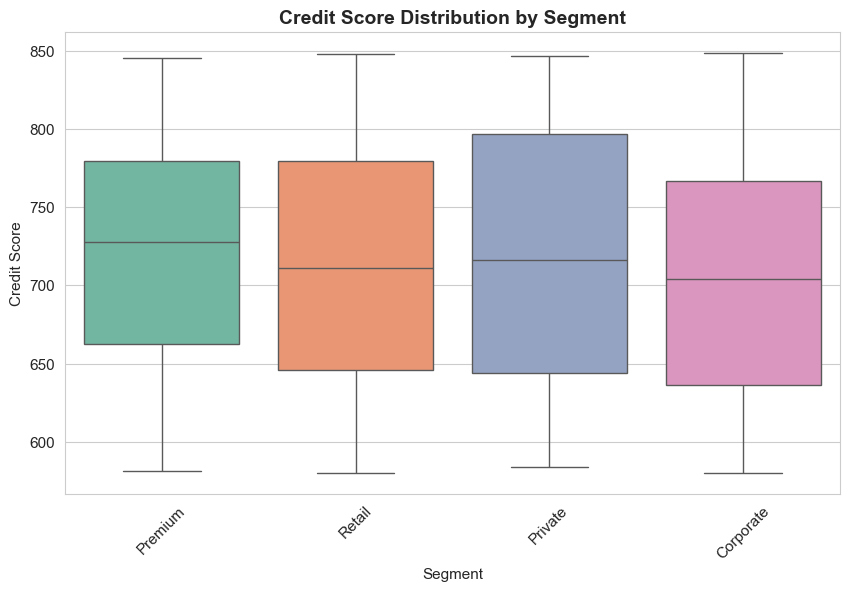

In [116]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customers, x='segment', y='credit_score', hue='segment', palette='Set2')
plt.title('Credit Score Distribution by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Credit Score')
plt.xticks(rotation=45)
plt.show()

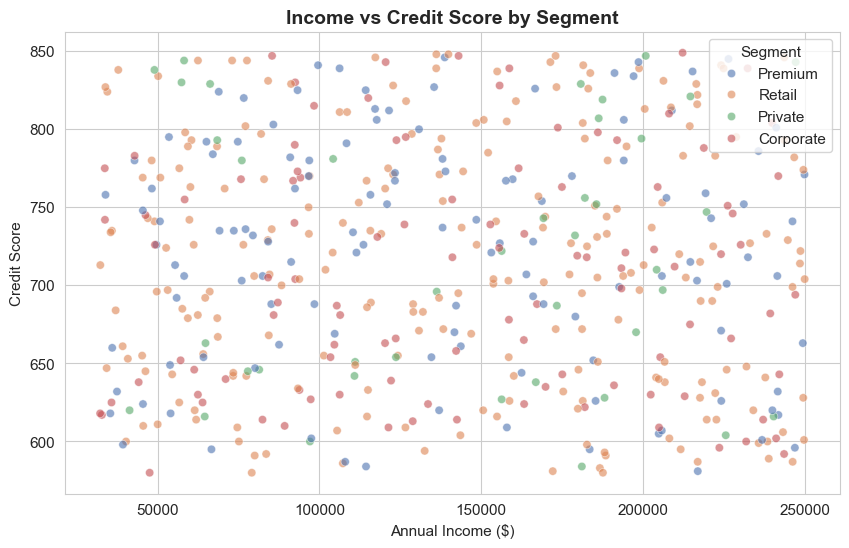

In [100]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers, x='annual_income', y='credit_score', 
                hue='segment', alpha=0.6, palette='deep')
plt.title('Income vs Credit Score by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income ($)')
plt.ylabel('Credit Score')
plt.ticklabel_format(style='plain', axis='x')
plt.legend(title='Segment')
plt.show()

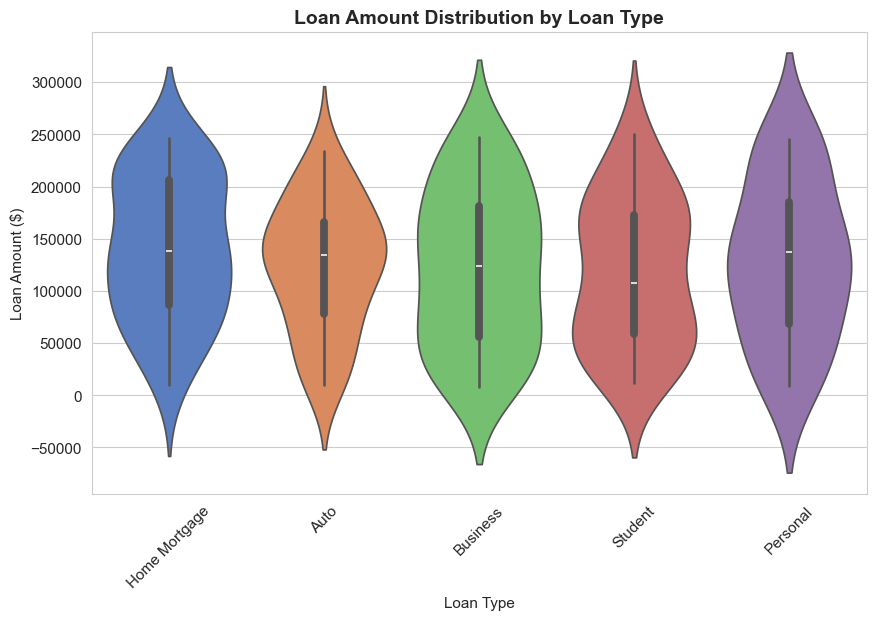

In [117]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=loans, x='loan_type', hue='loan_type', y='loan_amount', palette='muted')
plt.title('Loan Amount Distribution by Loan Type', fontsize=14, fontweight='bold')
plt.xlabel('Loan Type')
plt.ylabel('Loan Amount ($)')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

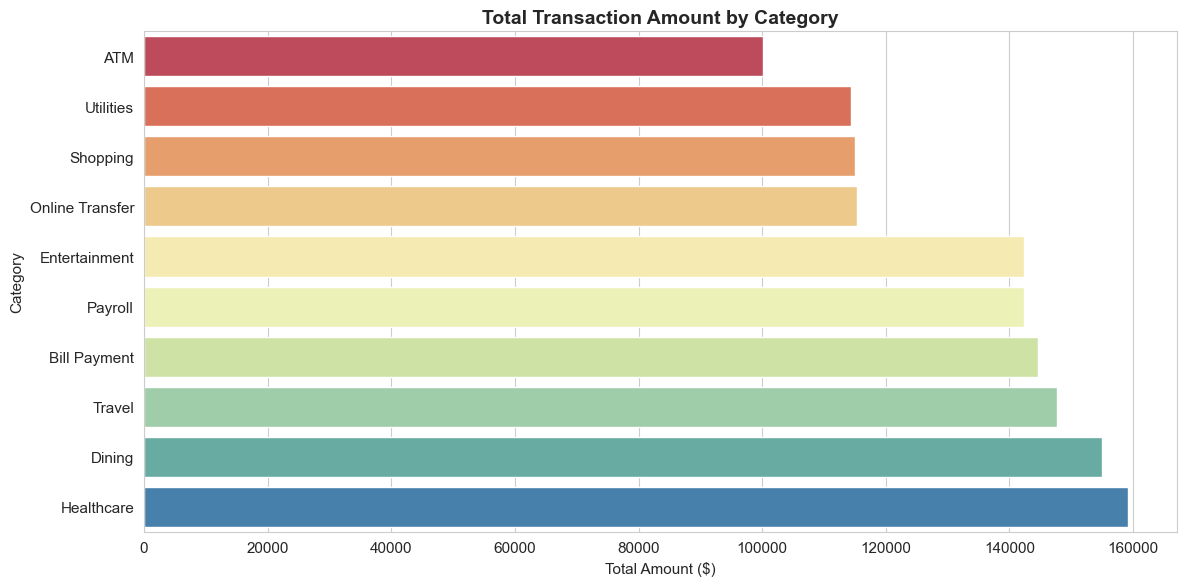

In [118]:
plt.figure(figsize=(12, 6))
category_totals = transactions.groupby('category')['amount'].sum().sort_values(ascending=True)
sns.barplot(x=category_totals.values, y=category_totals.index, hue=category_totals.index, palette='Spectral')
plt.title('Total Transaction Amount by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount ($)')
plt.ylabel('Category')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

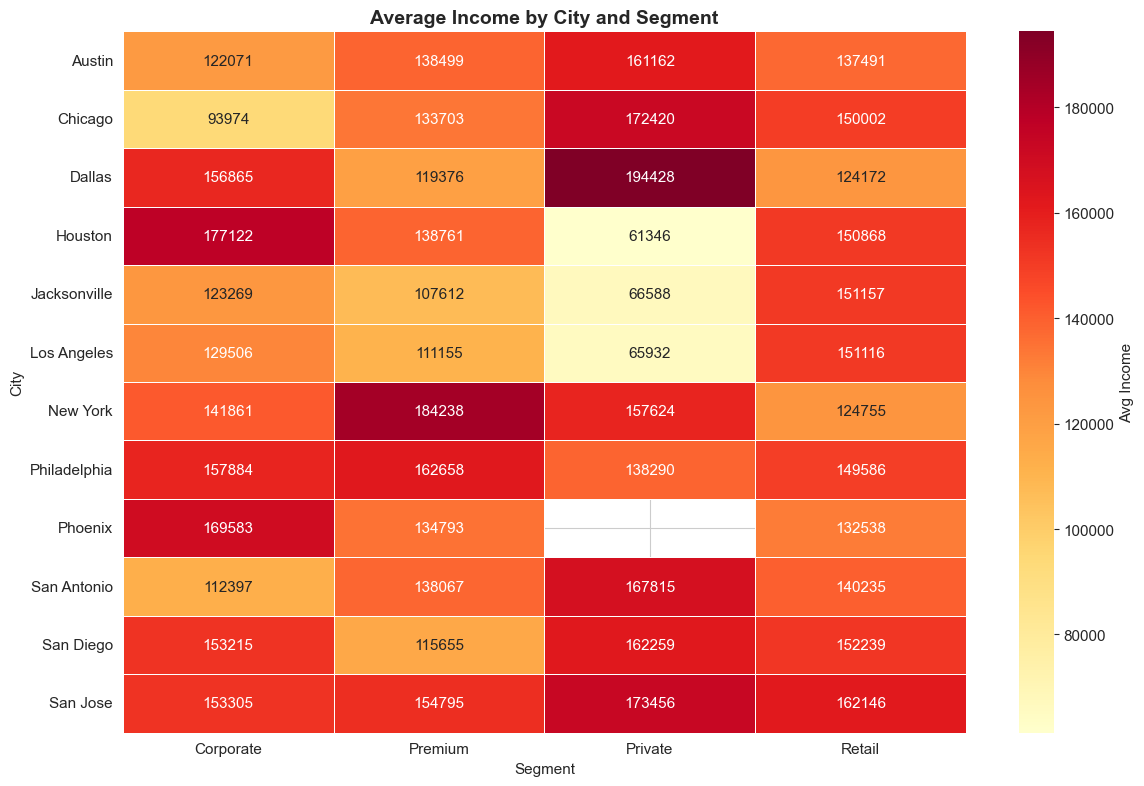

In [84]:
pivot_income = customers.pivot_table(values='annual_income', 
                                      index='city', 
                                      columns='segment', 
                                      aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_income, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Avg Income'})
plt.title('Average Income by City and Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('City')
plt.tight_layout()
plt.show()

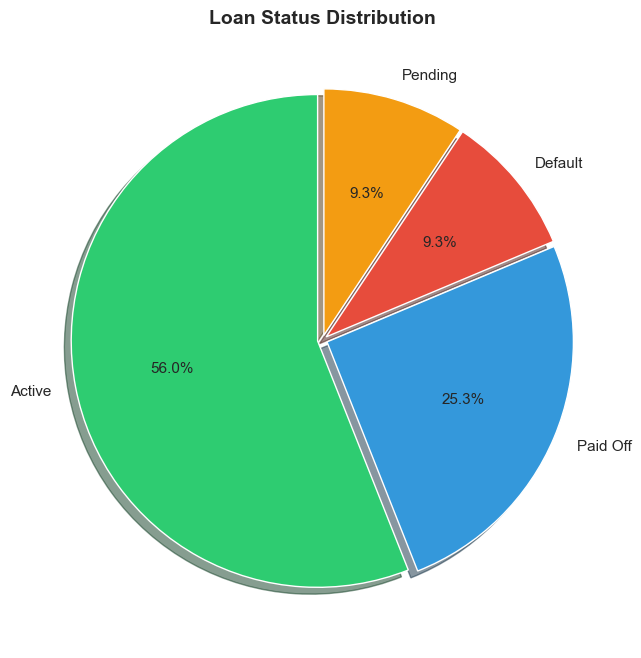

In [85]:
loan_status_counts = loans['status'].value_counts()
plt.figure(figsize=(8, 8))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
plt.pie(loan_status_counts.values, labels=loan_status_counts.index, 
        autopct='%1.1f%%', colors=colors, explode=[0.02]*len(loan_status_counts),
        shadow=True, startangle=90)
plt.title('Loan Status Distribution', fontsize=14, fontweight='bold')
plt.show()

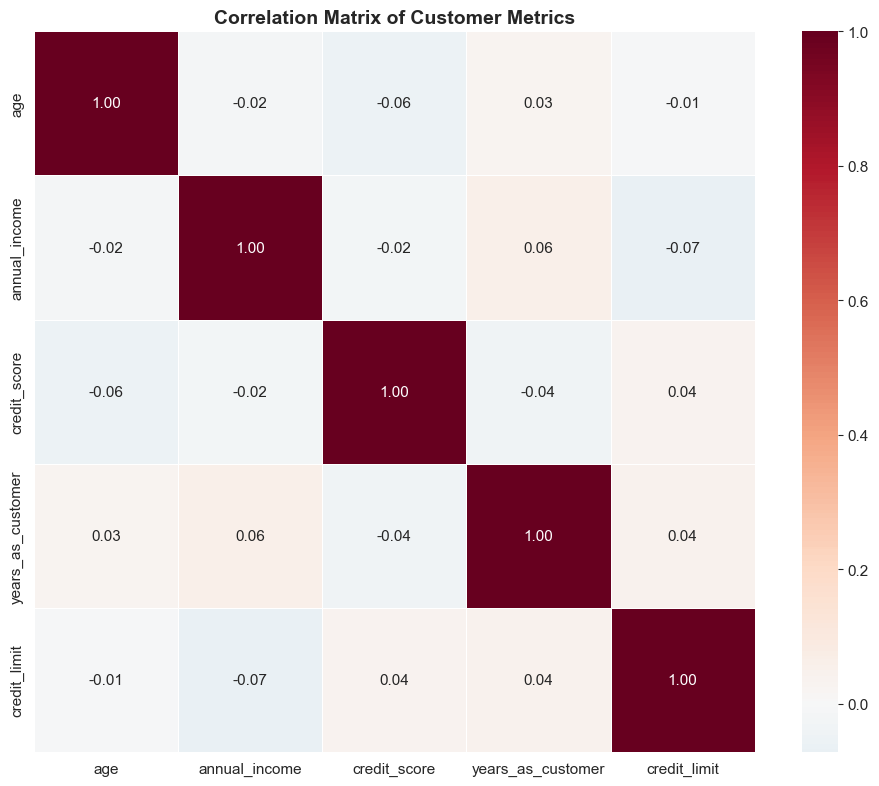

In [86]:
numeric_cols = customers[['age', 'annual_income', 'credit_score', 'years_as_customer', 'credit_limit']]
plt.figure(figsize=(10, 8))
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Customer Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Practice Exercises

In [87]:
# EXERCISE 1: Find the top 5 cities by total customer count
# YOUR CODE HERE:


city_counts = customers.groupby('city')['customer_id'].count().sort_values(ascending=False)
print("Top 5 cities by customer count:")
city_counts.head()

Top 5 cities by customer count:


city
San Antonio    48
New York       48
Dallas         46
Chicago        45
Phoenix        44
Name: customer_id, dtype: int64

In [88]:
# EXERCISE 2: Calculate the average transaction amount for each customer segment
# YOUR CODE HERE:


merged = customers.merge(transactions, on='customer_id')
segment_avg = merged.groupby('segment')['amount'].mean().round(2)
print("Average transaction amount by segment:")
segment_avg

Average transaction amount by segment:


segment
Corporate    615.43
Premium      717.36
Private      634.13
Retail       669.04
Name: amount, dtype: float64

In [89]:
# EXERCISE 3: Identify customers with credit score > 750 and income > $100K
# YOUR CODE HERE:


high_value_customers = customers[(customers['credit_score'] > 750) & 
                                  (customers['annual_income'] > 100000)]
print(f"Found {len(high_value_customers)} high-value customers")
high_value_customers[['customer_id', 'full_name', 'credit_score', 'annual_income', 'segment']]

Found 120 high-value customers


,customer_id,full_name,credit_score,annual_income,segment
6,CUST000007,Richard Thomas,848,136122,Retail
8,CUST000009,Michael Thomas,839,232346,Corporate
10,CUST000011,John Rodriguez,802,214456,Retail
12,CUST000013,David Anderson,826,166643,Premium
16,CUST000017,Patricia Davis,775,121218,Retail
...,...,...,...,...,...
484,CUST000485,Robert Davis,843,198616,Premium
490,CUST000491,Linda Martinez,783,222312,Retail
493,CUST000494,Susan Lopez,820,115076,Corporate
497,CUST000498,Barbara Brown,788,218799,Corporate


C:\Users\INUS\AppData\Local\Temp\ipykernel_20816\382309962.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loans, x='status', y='loan_amount', palette='pastel',


ValueError: The value for `errorbar` must be one of ['ci', 'pi', 'se', 'sd'], but 'mean' was passed.

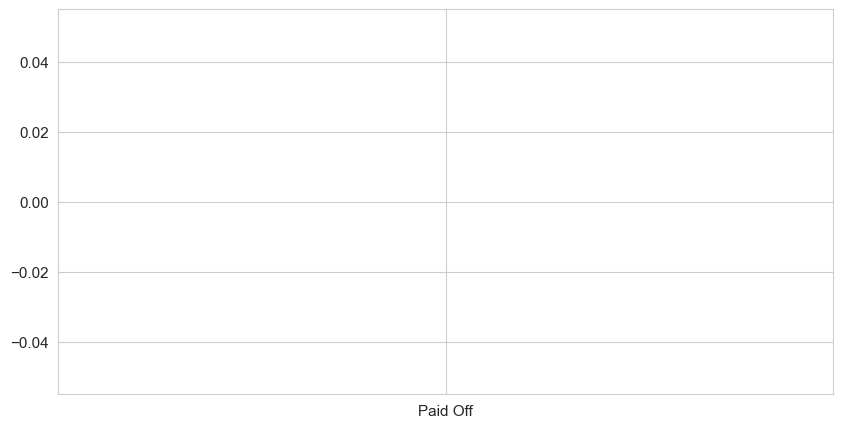

In [91]:
# EXERCISE 4: Create a visualization showing loan amounts by status
# YOUR CODE HERE:


plt.figure(figsize=(10, 5))
sns.barplot(data=loans, x='status', y='loan_amount', color='pastel', 
            )
plt.title('Average Loan Amount by Status', fontsize=14)
plt.xlabel('Loan Status')
plt.ylabel('Average Loan Amount ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Key Takeaways

### Pandas Essentials
- **DataFrame**: 2D tabular data structure with labeled rows and columns
- **Series**: Single column of data with an index
- **groupby()**: Split data into groups for aggregation
- **merge()**: Combine DataFrames like SQL joins
- **Filtering**: Use boolean conditions to select subsets

### Seaborn Visualization Types
- **Distribution**: histplot, kdeplot, violinplot
- **Categorical**: barplot, countplot, boxplot
- **Relational**: scatterplot, lineplot, regplot
- **Matrix**: heatmap for correlations

### Banking Analytics Applications
- Customer segmentation and profiling
- Transaction pattern analysis
- Loan portfolio risk assessment
- Credit risk scoring distributions

---
**Next Steps**: Explore real banking datasets (Kaggle, UCI ML Repository) and apply these techniques!